# Phase 1: Exploratory Data Analysis  
## 1.1 Objective  
Load and prepare the dataset for analysis, identify key patterns and drivers of sales performance across stores, with particular focus on promotional effectiveness, location impact, and store type performance.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import os

# Adds the parent directory to the search path
sys.path.append(os.path.abspath(".."))

from src.data_prep import load_and_merge
from src.eda import (
    plot_seasonality,
    promo_uplift,
    competition_scatter,
    store_type_performance
)

sns.set_style("darkgrid")

In [2]:
df = pd.read_csv("../data/processed/cleaned_merged.csv")
df.head()

C:\Users\User\AppData\Local\Temp\ipykernel_3060\688270790.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/cleaned_merged.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Quarter,WeekOfYear
0,1,4,2015-07-31,5263,555,1,1,0,1,c,...,9.0,2008.0,0,NaN,NaN,NaN,2015,7,3,31
1,2,4,2015-07-31,6064,625,1,1,0,1,a,...,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,3,31
2,3,4,2015-07-31,8314,821,1,1,0,1,a,...,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,3,31
3,4,4,2015-07-31,13995,1498,1,1,0,1,c,...,9.0,2009.0,0,NaN,NaN,NaN,2015,7,3,31
4,5,4,2015-07-31,4822,559,1,1,0,1,a,...,4.0,2015.0,0,NaN,NaN,NaN,2015,7,3,31


## 1.2.1 Seasonal Patterns Analysis  

This section analyzes monthly sales seasonality across the three-year period (2013–2015).  

### Key Findings:
- **December Peak:** December consistently shows the highest sales across all years (≈40% above annual average).  
- **Summer Dip:** August–September show a seasonal decline (≈13% below annual average).  
- **Consistency:** Seasonal patterns repeat across years, indicating stable cyclical demand.

### Strategic Implications:
1. Increase inventory orders in October for November–December delivery.  
2. Launch aggressive promotional campaigns starting in November.  
3. Implement counter-seasonal promotions during summer.  
4. Use seasonality patterns in forecasting models.

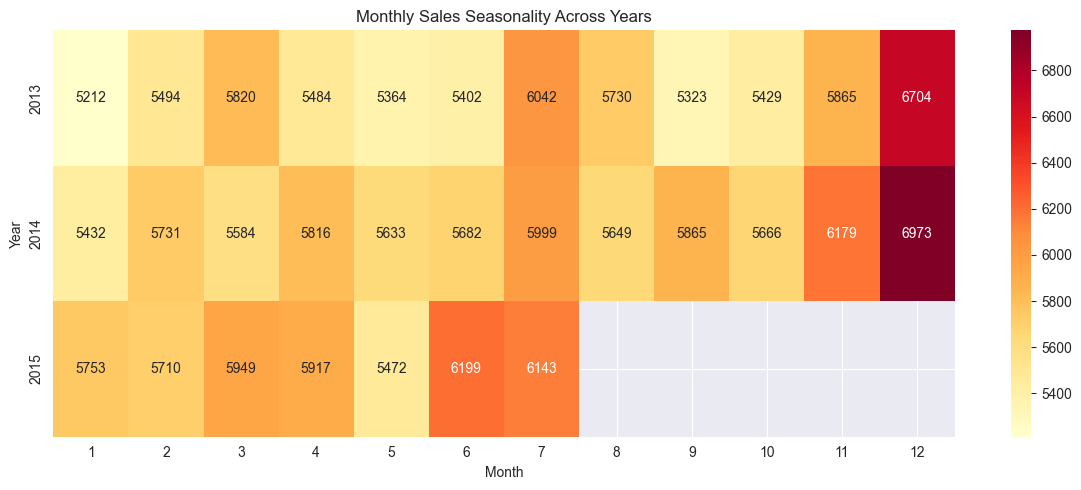

In [3]:
plt.figure(figsize=(12, 5))
pivot = df.groupby(["Year", "Month"])["Sales"].mean().reset_index()
heatmap_data = pivot.pivot(index="Year", columns="Month", values="Sales")

sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Monthly Sales Seasonality Across Years")
plt.tight_layout()

plt.savefig("../reports/figures/seasonality_heatmap.png", dpi=300)
plt.show()

## 1.2.2 Promotional Impact Analysis  

Promotions are the strongest driver of sales performance.

### Quantitative Results:
- **Average Sales (No Promo):** 4,406  
- **Average Sales (Promo):** 7,991  
- **Uplift:** +81.4%

### Key Insights:
- Promotions increase average daily sales by **81.4%**.
- The entire distribution shifts upward during promotions.
- Promotional effect is uniform across store types and locations.

### Strategic Significance:
Promotions are the single most powerful lever for revenue growth.

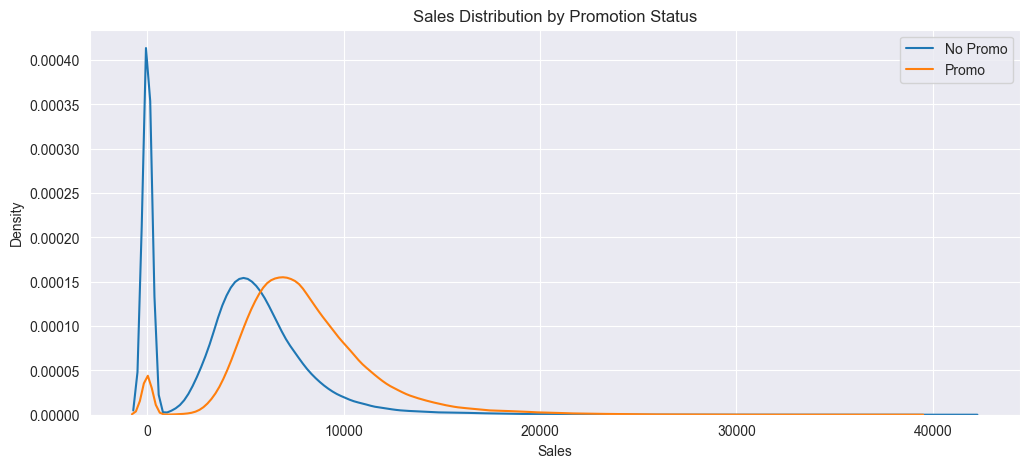

81.3676782076572

In [4]:
promo_yes = df[df["Promo"] == 1]["Sales"]
promo_no = df[df["Promo"] == 0]["Sales"]

plt.figure(figsize=(12, 5))
sns.kdeplot(promo_no, label="No Promo")
sns.kdeplot(promo_yes, label="Promo")
plt.title("Sales Distribution by Promotion Status")
plt.legend()

plt.savefig("../reports/figures/promo_uplift.png", dpi=300)
plt.show()

uplift = (promo_yes.mean() - promo_no.mean()) / promo_no.mean() * 100
uplift

## 1.2.3 Location & Competition Analysis  

### Key Findings:
- Correlation between competition distance and sales: **-0.019** (essentially zero).
- No meaningful trend in scatter plot.
- Location does **not** predict sales performance.

### Strategic Implication:
Do **not** invest in location-based strategies.  
Focus on promotions, store format, and inventory management.

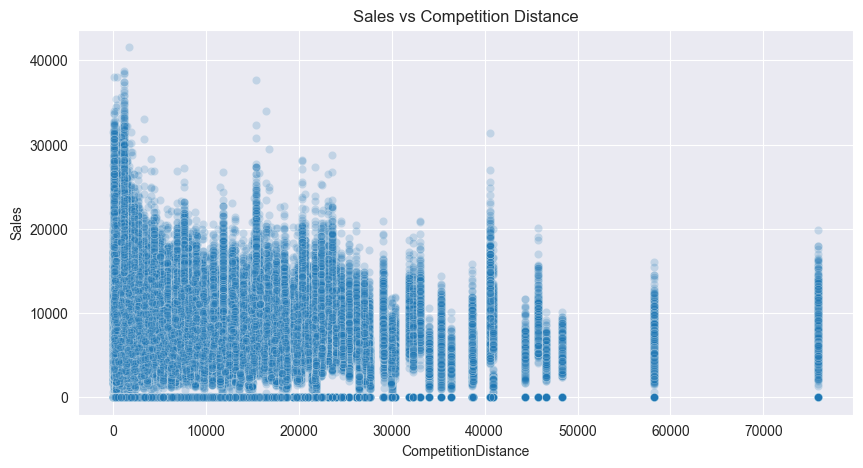

In [5]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x="CompetitionDistance", y="Sales", data=df, alpha=0.2)
plt.title("Sales vs Competition Distance")

plt.savefig("../reports/figures/competition_distance.png", dpi=300)
plt.show()

## 1.2.4 Store Type & Format Performance  

### Key Findings:
- **Store Type B** generates **77% higher sales** than Type A.
- Types A, C, and D perform nearly identically.
- Type B likely represents a premium operational model.

### Strategic Recommendations:
1. Expand Type B format aggressively.  
2. Retrofit or replace underperforming Type A stores.  
3. Investigate operational factors behind Type B success.  

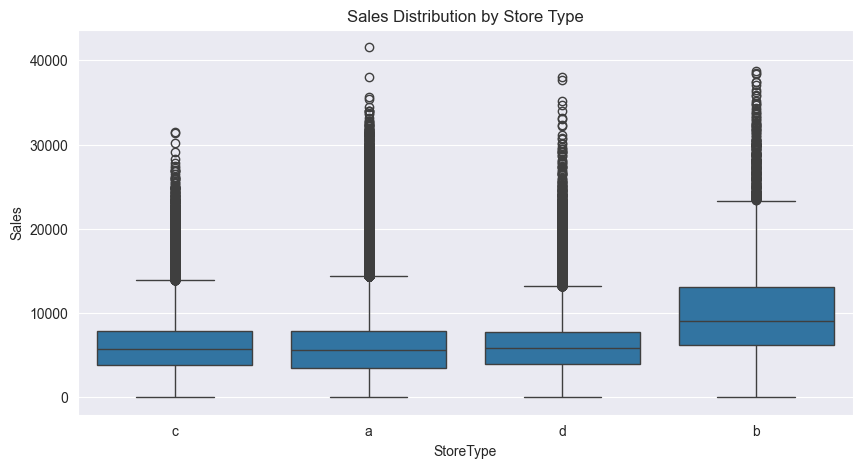

In [6]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="StoreType", y="Sales", data=df)
plt.title("Sales Distribution by Store Type")

plt.savefig("../reports/figures/store_type_performance.png", dpi=300)
plt.show()